In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

In [3]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import sklearn.utils as sku

# --------------------------------------------------------
# FILE IDS TO LOAD
# --------------------------------------------------------

file_ids = [
    "00",
    "01",
    "02",
    "03",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "14",
    "15",
    "16",
    "17",
    "18"
]

# --------------------------------------------------------
# LOAD ARTICLE MATRICES
# --------------------------------------------------------

data_list = [
    load_npz(f"Data_files/data_articles_{fid}.npz")
    for fid in file_ids
]

# --------------------------------------------------------
# LOAD LABEL FILES
# --------------------------------------------------------

label_list = [
    np.genfromtxt(
        f"Data_files/labels_articles_{fid}.txt",
        delimiter="; ",
        dtype=str,
        encoding="latin1"
    )
    for fid in file_ids
]

# --------------------------------------------------------
# CREATE COMBINED DATASET
# --------------------------------------------------------

data_articles_all = sparse.vstack(
    data_list,
    format="csr"
)

labels_articles_all = np.vstack(
    label_list
)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------
# index = 0 -> date
# index = 1 -> sermon or not
# index = 2 -> article title
# index = 3 -> article topic
# index = 4 -> lix score
# --------------------------------------------------------

# --------------------------------------------------------
# KEEP ONLY TOP X MOST FREQUENT TOPICS
# --------------------------------------------------------

top_x = 10

topics = labels_articles_all[:, 3]

unique_topics, topic_counts = np.unique(
    topics,
    return_counts=True
)

sorted_indices = np.argsort(topic_counts)[::-1]

valid_topics = unique_topics[
    sorted_indices[:top_x]
]

keep_mask = np.isin(
    topics,
    valid_topics
)

print("Original number of articles:", data_articles_all.shape[0])
print("Filtered number of articles:", keep_mask.sum())
print("Removed articles:", data_articles_all.shape[0] - keep_mask.sum())

print("\nTop topics kept:")
for topic in valid_topics:
    count = np.sum(topics == topic)
    print(f"{topic}: {count}")

data_articles_all = data_articles_all[keep_mask]
labels_articles_all = labels_articles_all[keep_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# SHUFFLE DATA AND LABELS
# --------------------------------------------------------

data_articles_all, labels_articles_all = sku.shuffle(
    data_articles_all,
    labels_articles_all,
    random_state=5466542
)

# --------------------------------------------------------
# SORT COLUMNS AND KEEP FIRST 251 FEATURES
# --------------------------------------------------------

sort_idx = np.genfromtxt(
    "txt_files/speeches_sort_idx.txt",
    delimiter="\n",
    dtype=int
)

data_articles_all = data_articles_all[:, sort_idx][:, :251]

print("Shape after column sorting/top 251:", data_articles_all.shape)

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN
# --------------------------------------------------------

lix_scores = labels_articles_all[:, 4].astype(np.float32)

assert data_articles_all.shape[0] == len(lix_scores)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_articles_all = sparse.hstack(
    [lix_column, data_articles_all],
    format="csr"
)

# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(
    with_mean=False
)

data_articles_all = scaler.fit_transform(
    data_articles_all
)

# --------------------------------------------------------
# CONVERT TOPICS TO INTEGER LABELS
# --------------------------------------------------------

topic_labels = labels_articles_all[:, 3]

label_encoder = LabelEncoder()

topic_labels_encoded = label_encoder.fit_transform(
    topic_labels
)

# --------------------------------------------------------
# SPLIT DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(
    data_articles_all,
    topic_labels_encoded,
    val_size=0.20,
    test_size=0
)

# --------------------------------------------------------
# FINAL OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_articles_all.shape)
print("Final number of labels:", labels_articles_all.shape[0])

print("\nExample feature row:")
print(data_articles_all[0])

print("\nExample label row:")
print(labels_articles_all[0])

Initial data shape: (853077, 27000)
Initial number of labels: 853077
Original number of articles: 853077
Filtered number of articles: 504327
Removed articles: 348750

Top topics kept:
Danmark: 150348
Internationalt: 144647
Sport: 42216
Kultur: 35301
Politik: 34656
Økonomi: 30938
Fodbold: 27503
Forbrug: 13721
Film og tv: 13120
Cykling: 11877
Shape after column sorting/top 251: (504327, 251)

Final data shape: (504327, 252)
Final number of labels: 504327

Example feature row:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 25 stored elements and shape (1, 252)>
  Coords	Values
  (0, 0)	7.266957653619334
  (0, 247)	6.64640962323575
  (0, 216)	3.479544869491937
  (0, 69)	2.1771270770203697
  (0, 203)	1.7844864653321375
  (0, 245)	2.309386654358611
  (0, 148)	1.9825525612462012
  (0, 165)	1.5013883174054186
  (0, 127)	1.7542889663699366
  (0, 27)	1.923501104258867
  (0, 251)	1.8687595466266833
  (0, 184)	5.19110967281735
  (0, 188)	2.8664672168446583
  (0, 185)	2.3514236594116

# Functions

In [4]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)

In [5]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [6]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [7]:
def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    Layer1 = trial.suggest_int("Layer1", 64, 256)
    Layer2 = trial.suggest_int("Layer2", 32, 128)
    Layer3 = trial.suggest_int("Layer3", 8, 64)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    n_epochs = 10

    input_dim = data_train.shape[1]
    num_classes = len(label_encoder.classes_)

    class OptModel(nn.Module):

        def __init__(self):
            super(OptModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, num_classes)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptModel().to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=sparse_collate
    )

    validation_loader = DataLoader(
        dataset=val_data,
        batch_size=batch_size,
        collate_fn=sparse_collate
    )

    best_validation_loss = float("inf")

    for epoch in range(n_epochs):

        print(f"Trial {trial.number} | Optuna epoch {epoch + 1}/{n_epochs}")

        training_loss, validation_loss = Train(
            model_opt,
            optimizer,
            loss_function,
            train_loader,
            validation_loader,
            device,
            1)

        current_validation_loss = validation_loss[-1]

        best_validation_loss = min(
            best_validation_loss,
            current_validation_loss
        )

        trial.report(current_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

# HP optimization

In [8]:
pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

study.optimize(
    objective,
    n_trials=30
)

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

[I 2026-06-05 15:43:33,020] A new study created in memory with name: no-name-c3da2584-33c2-41b7-9769-636b50b12cee


Trial 0 | Optuna epoch 1/10


/var/folders/rp/p2_g6d3j74ggpl15kr0_k5zc0000gn/T/ipykernel_19153/936182257.py:23: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()


EPOCH: 1 | training loss: 1.778  | validation loss: 1.509
Trial 0 | Optuna epoch 2/10
EPOCH: 1 | training loss: 1.596  | validation loss: 1.456
Trial 0 | Optuna epoch 3/10
EPOCH: 1 | training loss: 1.549  | validation loss: 1.413
Trial 0 | Optuna epoch 4/10
EPOCH: 1 | training loss: 1.517  | validation loss: 1.382
Trial 0 | Optuna epoch 5/10
EPOCH: 1 | training loss: 1.493  | validation loss: 1.356
Trial 0 | Optuna epoch 6/10
EPOCH: 1 | training loss: 1.476  | validation loss: 1.337
Trial 0 | Optuna epoch 7/10
EPOCH: 1 | training loss: 1.461  | validation loss: 1.324
Trial 0 | Optuna epoch 8/10
EPOCH: 1 | training loss: 1.45  | validation loss: 1.308
Trial 0 | Optuna epoch 9/10
EPOCH: 1 | training loss: 1.441  | validation loss: 1.299
Trial 0 | Optuna epoch 10/10


[I 2026-06-05 15:50:01,599] Trial 0 finished with value: 1.2913925340168826 and parameters: {'learning_rate': 9.878918031772565e-05, 'batch_size': 64, 'Layer1': 231, 'Layer2': 84, 'Layer3': 14, 'dropout_rate': 0.4637942926639987}. Best is trial 0 with value: 1.2913925340168826.


...

EPOCH: 1 | training loss: 1.288  | validation loss: 1.215
Trial 28 | Optuna epoch 1/10
EPOCH: 1 | training loss: 1.433  | validation loss: 1.258
Trial 28 | Optuna epoch 2/10


[I 2026-06-05 16:30:18,257] Trial 28 pruned. 


EPOCH: 1 | training loss: 1.295  | validation loss: 1.21
Trial 29 | Optuna epoch 1/10
EPOCH: 1 | training loss: 1.432  | validation loss: 1.255
Trial 29 | Optuna epoch 2/10


[I 2026-06-05 16:30:59,920] Trial 29 pruned. 


EPOCH: 1 | training loss: 1.307  | validation loss: 1.21
Best trial:
FrozenTrial(number=1, state=<TrialState.COMPLETE: 1>, values=[1.1301571399592574], datetime_start=datetime.datetime(2026, 6, 5, 15, 50, 1, 600934), datetime_complete=datetime.datetime(2026, 6, 5, 15, 57, 50, 738004), params={'learning_rate': 0.00035795019925370154, 'batch_size': 32, 'Layer1': 230, 'Layer2': 95, 'Layer3': 56, 'dropout_rate': 0.23374546520995243}, user_attrs={}, system_attrs={}, intermediate_values={0: 1.2366020847436854, 1: 1.191431445401319, 2: 1.1689286467634306, 3: 1.1572134741291031, 4: 1.1520186449234784, 5: 1.1390533701833037, 6: 1.1418769443912749, 7: 1.1336324969043703, 8: 1.1339265236065685, 9: 1.1301571399592574}, distributions={'learning_rate': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(32, 64, 128)), 'Layer1': IntDistribution(high=256, log=False, low=64, step=1), 'Layer2': IntDistribution(high=128, log=False, low=32, step=1),

In [15]:
print(study.best_trial.params)

{'learning_rate': 0.00035795019925370154, 'batch_size': 32, 'Layer1': 230, 'Layer2': 95, 'Layer3': 56, 'dropout_rate': 0.23374546520995243}


# Split data for actual training

In [16]:
# --------------------------------------------------------
# split data into train, val, test sets
# --------------------------------------------------------

data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(
    data_articles_all,
    topic_labels_encoded,
    val_size=0.20,
    test_size=0.1
)

# Train the data with HP optimized parameters

In [17]:
best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

dropout_rate = best_params["dropout_rate"]

n_epochs = 10

input_dim = data_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Starting setup...")
print("Best hyperparameters:", best_params)
print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

class TopicModel(nn.Module):

    def __init__(self):
        super(TopicModel, self).__init__()

        self.input_layer = nn.Linear(input_dim, Layer1)
        self.hidden_layer1 = nn.Linear(Layer1, Layer2)
        self.hidden_layer2 = nn.Linear(Layer2, Layer3)
        self.output_layer = nn.Linear(Layer3, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, inputs):

        x = self.input_layer(inputs)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.output_layer(x)

        return x


print("Selecting device...")
device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
print("Using device:", device)

print("Creating model...")
model = TopicModel().to(device)
print("Model created.")

print("Creating optimizer...")
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
print("Optimizer created.")

print("Creating loss function...")
loss_function = CrossEntropyLoss()
print("Loss function created.")

print("Creating data loaders...")
train_loader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=sparse_collate
)

validation_loader = DataLoader(
    dataset=val_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

print("Data loaders created.")
print("Starting training...")

training_loss, validation_loss = Train(
    model,
    optimizer,
    loss_function,
    train_loader,
    validation_loader,
    device,
    n_epochs
)

print("Training finished.")
print("Training losses:")
print(training_loss)

print("Validation losses:")
print(validation_loss)

Starting setup...
Best hyperparameters: {'learning_rate': 0.00035795019925370154, 'batch_size': 32, 'Layer1': 230, 'Layer2': 95, 'Layer3': 56, 'dropout_rate': 0.23374546520995243}
Input dimension: 252
Number of classes: 10
Selecting device...
Using device: cpu
Creating model...
Model created.
Creating optimizer...
Optimizer created.
Creating loss function...
Loss function created.
Creating data loaders...
Data loaders created.
Starting training...
EPOCH: 1 | training loss: 1.383  | validation loss: 1.23
EPOCH: 2 | training loss: 1.176  | validation loss: 1.172
EPOCH: 3 | training loss: 1.118  | validation loss: 1.149
EPOCH: 4 | training loss: 1.085  | validation loss: 1.132
EPOCH: 5 | training loss: 1.063  | validation loss: 1.127
EPOCH: 6 | training loss: 1.045  | validation loss: 1.119
EPOCH: 7 | training loss: 1.031  | validation loss: 1.123
EPOCH: 8 | training loss: 1.02  | validation loss: 1.128
EPOCH: 9 | training loss: 1.01  | validation loss: 1.131
EPOCH: 10 | training loss: 1.

# Plotting the results

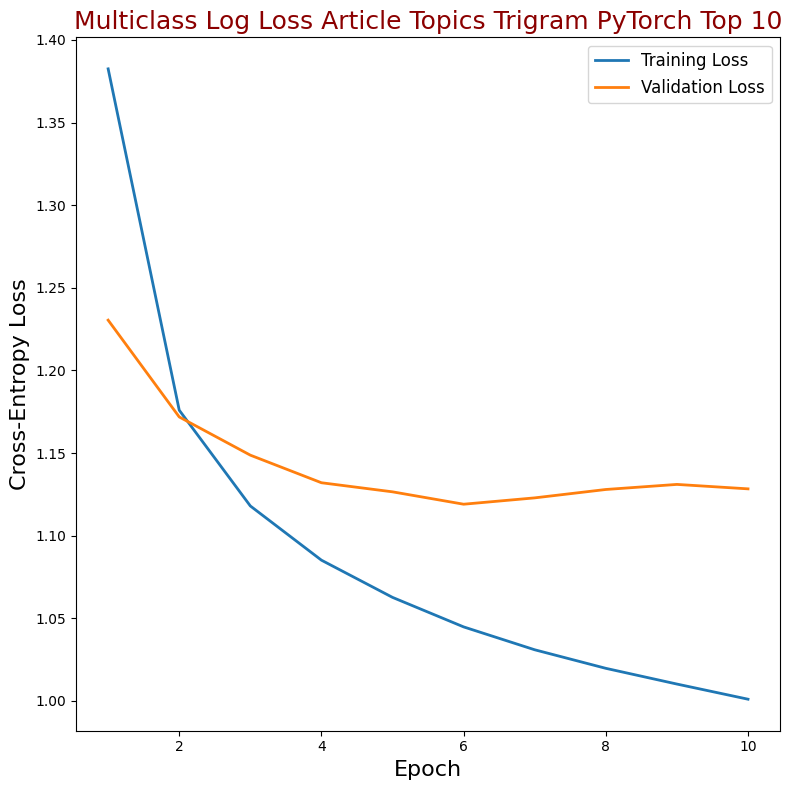


FINAL TEST RESULTS
Cross-Entropy Loss : 1.1284
Log Loss           : 1.1287
Accuracy           : 0.5994
Macro F1           : 0.5197
Weighted F1        : 0.5921


In [18]:
# --------------------------------------------------------
# PLOT TRAINING / VALIDATION LOG LOSS
# AND EVALUATE FINAL TEST PERFORMANCE
# --------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss
)

# --------------------------------------------------------
# LOSS CURVE
# --------------------------------------------------------

epochs = np.arange(
    1,
    len(training_loss) + 1
)

plt.figure(figsize=(8, 8))

plt.plot(
    epochs,
    training_loss,
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch",
    fontsize=16
)

plt.ylabel(
    "Cross-Entropy Loss",
    fontsize=16
)

plt.title(
    "Multiclass Log Loss Article Topics Trigram PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "Multiclass_LogLoss_ArticleTopics_TrigramPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------------
# TEST / VALIDATION SET EVALUATION
# --------------------------------------------------------

test_data = val_data   # use validation set as test set for now

test_loader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

model.eval()

all_probabilities = []
all_predictions = []
all_truths = []

test_loss = 0.0
n_batches = 0

with pt.no_grad():

    for input_batch, truth_batch in test_loader:

        input_batch = input_batch.to(device)
        truth_batch = truth_batch.to(device)

        outputs = model(input_batch)

        loss = loss_function(
            outputs,
            truth_batch.long()
        )

        test_loss += loss.item()
        n_batches += 1

        probabilities = pt.softmax(outputs, dim=1)
        predictions = pt.argmax(outputs, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_truths.extend(truth_batch.cpu().numpy())

# --------------------------------------------------------
# FINAL METRICS
# --------------------------------------------------------

all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)
all_truths = np.array(all_truths)

final_test_loss = test_loss / n_batches

final_log_loss = log_loss(
    all_truths,
    all_probabilities
)

test_accuracy = accuracy_score(
    all_truths,
    all_predictions
)

macro_f1 = f1_score(
    all_truths,
    all_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    all_truths,
    all_predictions,
    average="weighted"
)

# --------------------------------------------------------
# REPORT RESULTS
# --------------------------------------------------------

print("\n" + "=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print(
    f"Cross-Entropy Loss : {final_test_loss:.4f}"
)

print(
    f"Log Loss           : {final_log_loss:.4f}"
)

print(
    f"Accuracy           : {test_accuracy:.4f}"
)

print(
    f"Macro F1           : {macro_f1:.4f}"
)

print(
    f"Weighted F1        : {weighted_f1:.4f}"
)

print("=" * 50)

Generating predictions...


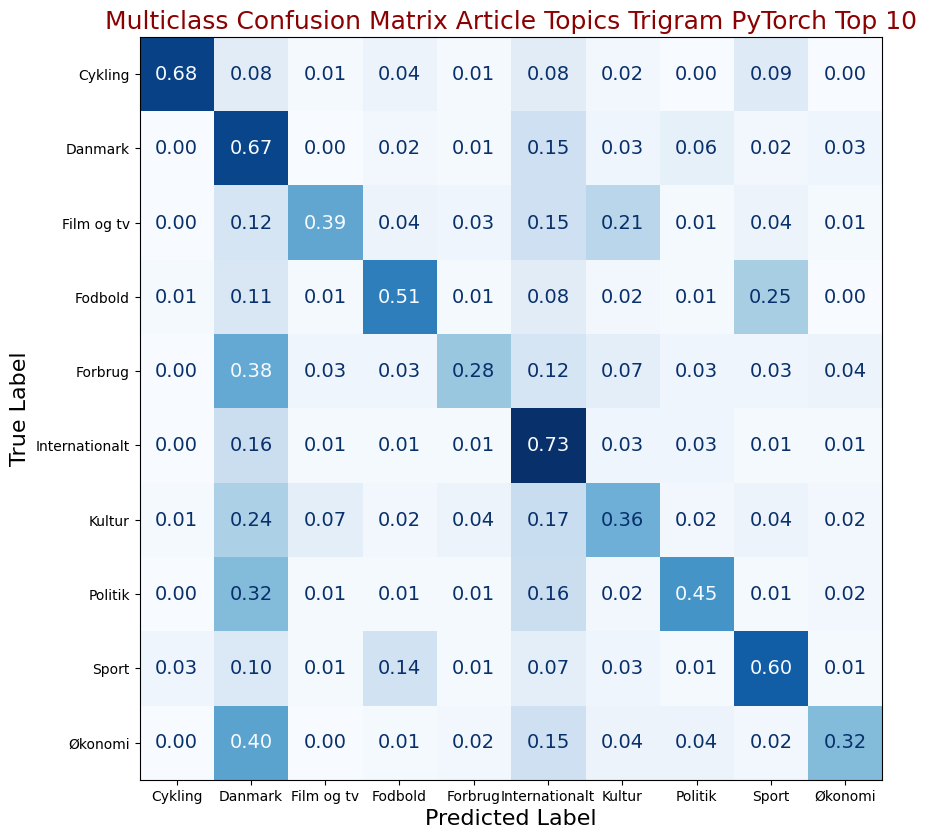

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET VALIDATION PREDICTIONS
# --------------------------------------------------------

model.eval()

all_predictions = []
all_truths = []

print("Generating predictions...")

with pt.no_grad():

    for input_batch, truth_batch in validation_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)

        predictions = pt.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_truths.extend(
            truth_batch.cpu().numpy()
        )

# --------------------------------------------------------
# NORMALIZED CONFUSION MATRIX
# --------------------------------------------------------

cm = confusion_matrix(
    all_truths,
    all_predictions,
    normalize="true"
)

# Force 2 decimals
cm = np.round(cm, 2)

classes = label_encoder.classes_

# --------------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(9, 9))

disp.plot(
    ax=ax,
    xticks_rotation=0,
    cmap=plt.cm.Blues,
    colorbar=False,
    values_format=".2f"   # FORCE 2 DECIMALS
)

for t in disp.text_.ravel():
    t.set_fontsize(14)

plt.title(
    "Multiclass Confusion Matrix Article Topics Trigram PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel(
    "Predicted Label",
    fontsize=16
)

plt.ylabel(
    "True Label",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "Multiclass_ConfusionMatrix_ArticleTopics_TrigramPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Generating prediction probabilities...


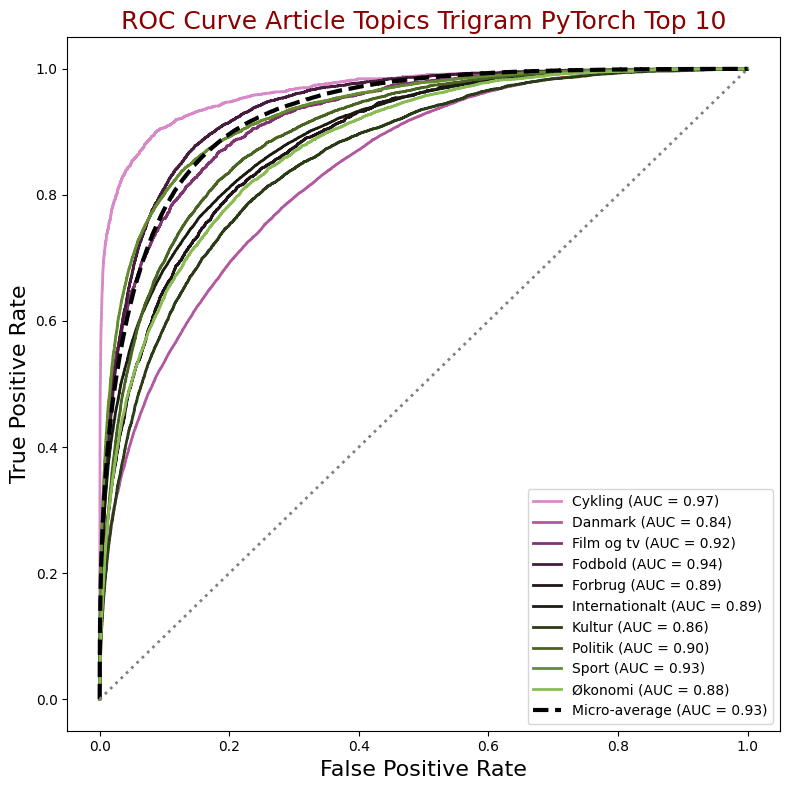

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET VALIDATION PROBABILITIES
# --------------------------------------------------------

model.eval()

all_probabilities = []
all_truths = []

print("Generating prediction probabilities...")

with pt.no_grad():

    for input_batch, truth_batch in validation_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)

        probabilities = pt.softmax(outputs, dim=1)

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_truths.extend(
            truth_batch.cpu().numpy()
        )

all_probabilities = np.array(all_probabilities)
all_truths = np.array(all_truths)

# --------------------------------------------------------
# BINARIZE LABELS FOR MULTICLASS ROC
# --------------------------------------------------------

classes = label_encoder.classes_
num_classes = len(classes)

truths_binarized = label_binarize(
    all_truths,
    classes=np.arange(num_classes)
)

# --------------------------------------------------------
# COMPUTE ROC CURVES
# --------------------------------------------------------

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        truths_binarized[:, i],
        all_probabilities[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# --------------------------------------------------------
# MICRO-AVERAGE ROC
# --------------------------------------------------------

fpr["micro"], tpr["micro"], _ = roc_curve(
    truths_binarized.ravel(),
    all_probabilities.ravel()
)

roc_auc["micro"] = auc(
    fpr["micro"],
    tpr["micro"]
)

# --------------------------------------------------------
# VANIMO COLOR MAP
# --------------------------------------------------------

cmap = plt.get_cmap("vanimo")

colors = cmap(
    np.linspace(0.1, 0.9, num_classes)
)

# --------------------------------------------------------
# PLOT ROC CURVES
# --------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

for i, color in zip(range(num_classes), colors):

    ax.plot(
        fpr[i],
        tpr[i],
        color=color,
        linewidth=2,
        label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

# Micro-average ROC
ax.plot(
    fpr["micro"],
    tpr["micro"],
    color="black",
    linestyle="--",
    linewidth=3,
    label=f"Micro-average (AUC = {roc_auc['micro']:.2f})"
)

# Random classifier line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=2,
    color="gray"
)

plt.title(
    "ROC Curve Article Topics Trigram PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=16
)

plt.ylabel(
    "True Positive Rate",
    fontsize=16
)

plt.legend(
    fontsize=10,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    "Multiclass_ROC_ArticleTopics_TrigramPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()